In [1]:
import numpy as np
import pandas as pd
from scipy import integrate
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import os,sys
from copy import deepcopy
import pickle
from importlib.machinery import SourceFileLoader
# Get the absolute path of the script's directory
script_dir = os.path.abspath('')
# Define the relative path to the module
relative_module_path = "../rguimera-machine-scientist/parallel.py"
# Get the full absolute path
path = os.path.join(script_dir, relative_module_path)
ms = SourceFileLoader("ms", path).load_module()


#Import prior
path = os.path.join(os.path.abspath(''), "../rguimera-machine-scientist/Prior/")
sys.path.append(path)
from fit_prior import read_prior_par
prior = read_prior_par('../rguimera-machine-scientist/Prior/final_prior_param_sq.named_equations.nv1.np8.2017-10-18 18:07:35.261518.dat')

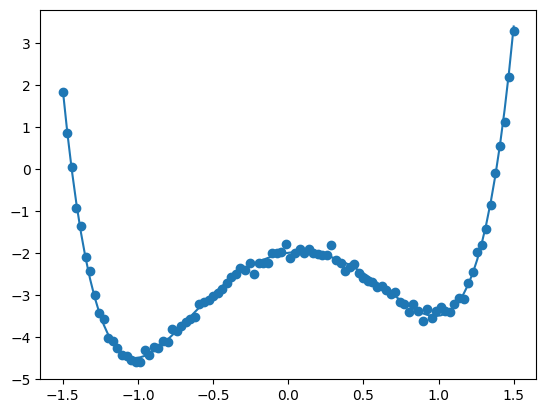

182.139889369086
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
-(_a5_)
-(_a5_)
-(_a5_)
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_
_a3_

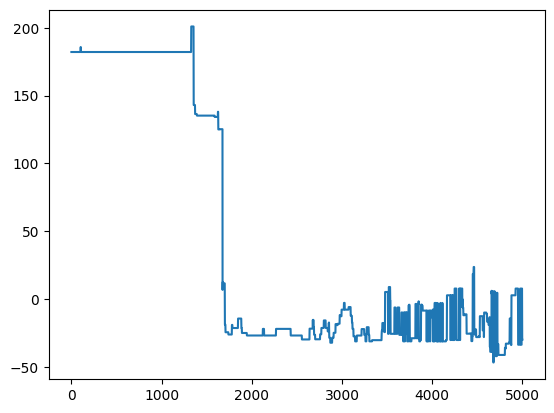

In [2]:
# Generate a dataset and sample models with the BMS

def f(x,theta):
    return theta[0] * x**6. + theta[1]*x**2. + theta[2] + theta[3]*x
n= 100

s = 0.1
x_n = np.linspace(-1.5,1.5,n)
theta_hat = np.array([1.,-3.,-2,0.5,s])
data = f(x_n,theta_hat[:-1])
noisy_data = data + np.random.normal(scale=s, size=len(data))

plt.plot(x_n,data)
plt.scatter(x_n,noisy_data)
plt.show()

# Initialize the BMS
pms = ms.Parallel(x = pd.DataFrame(data={'x':x_n}), y = pd.Series(noisy_data),
        Ts = [1] + [1.04**k for k in range(1, 20)],
        prior_par=prior, variables=['x'],parameters=['a%d' % i for i in range(8)])

print(pms.t1.E)

models = {}
dl = []
for i in range(5000):
    pms.mcmc_step()
    pms.tree_swap()
    print(pms.t1)
    if pms.t1.canonical() not in list(models.keys()):
        models.update({pms.t1.canonical():deepcopy(pms.t1)})
    dl.append(pms.t1.E)
print(models)
plt.plot(dl)
plt.show()

with open('1d_data_models.pkl','wb') as file:
    pickle.dump(models,file=file)

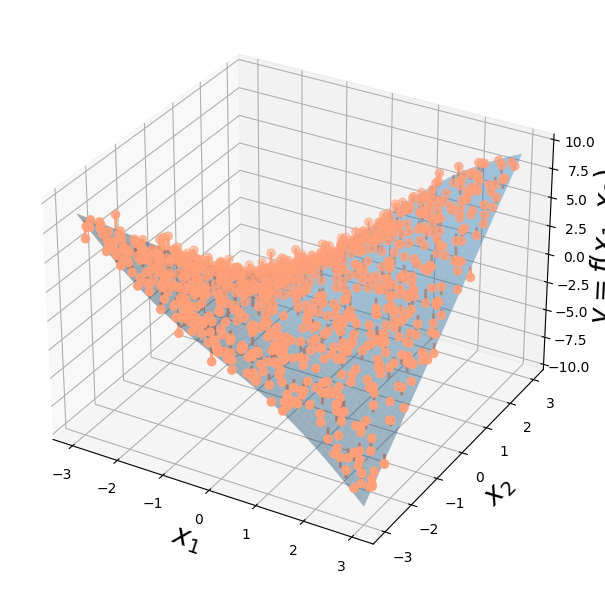

2596.19540265023
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
_a4_
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
tanh(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin(x)
sin

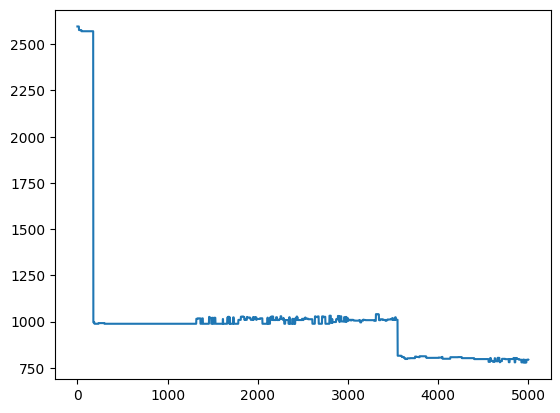

In [3]:
prior = read_prior_par('../rguimera-machine-scientist/Prior/final_prior_param_sq.named_equations.nv2.np8.2016-09-09 18:49:42.800618.dat')
def f(x, y):
    return np.sin(x) +x*y

# Create a grid for the surface
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)
s=0.5
# Sample noisy points
n_samples = 1000
xs = np.random.uniform(-3, 3, n_samples)
ys = np.random.uniform(-3, 3, n_samples)
true_zs = f(xs, ys)
noise = np.random.normal(scale=s, size=len(true_zs))
noisy_zs = true_zs + noise

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# True surface
ax.plot_surface(X, Y, Z, alpha=0.4)

# Noisy observations
ax.scatter(xs, ys, noisy_zs, s=35,c='lightsalmon')

# True points on the surface (IMPORTANT)
#ax.scatter(xs, ys, true_zs, s=25)

# Vertical noise lines
for i in range(n_samples):
    ax.plot(
        [xs[i], xs[i]],
        [ys[i], ys[i]],
        [true_zs[i], noisy_zs[i]],
        linewidth=2,c='lightsalmon'
    )


# Labels
ax.set_xlabel('$x_1$',fontsize = 20)
ax.set_ylabel('$x_2$',fontsize = 20)
ax.set_zlabel('$y=f(x_1, x_2)$',fontsize = 20)

plt.tight_layout()
plt.savefig('SR_surface_noise.png',dpi=300)
plt.show()


# Initialize the BMS
pms = ms.Parallel(x = pd.DataFrame(data={'x':xs,'y':ys}), y = pd.Series(noisy_zs),
        Ts = [1] + [1.04**k for k in range(1, 20)],
        prior_par=prior, variables=['x','y'],parameters=['a%d' % i for i in range(8)])

print(pms.t1.E)

models = {}
dl = []
for i in range(5000):
    pms.mcmc_step()
    pms.tree_swap()
    print(pms.t1)
    if pms.t1.canonical() not in list(models.keys()):
        models.update({pms.t1.canonical():deepcopy(pms.t1)})
    dl.append(pms.t1.E)
print(models)
plt.plot(dl)
plt.show()

with open('2d_data_models.pkl','wb') as file:
    pickle.dump(models,file=file)